In [2]:
import pandas as pd
import numpy as np

## Initial Data Understanding

In [3]:
import pandas as pd

df = pd.read_excel(
    r"D:\Marketing_Campaign_Analysis\dataset\Marketing_Campaign_Data_Original.xlsx"
)

df.head()


,Date,CampaignID,CampaignName,Platform,TargetAudience,Impressions,Clicks,Leads,Applications,Enrollments,Cost (₹),Revenue (₹),Region
0,2024-01-01,AD004,Hackathon,YouTube,17–21 Age,285708,16956,4087,2547,1148,275457.87,4615838.04,West India
1,2024-01-02,AD004,Hackathon,YouTube,17–21 Age,140449,10082,1815,951,565,133025.86,3513169.90,North India
2,2024-01-03,AD004,Hackathon,YouTube,17–21 Age,140958,7474,1169,683,343,135765.61,1051924.88,North India
3,2024-01-04,AD004,Hackathon,YouTube,22–27 Age,257823,16841,3179,1584,698,229715.44,3850639.56,West India
4,2024-01-05,AD004,Hackathon,YouTube,25–35 Age,98595,7293,1340,854,368,52360.96,1543262.86,West India


In [4]:
df.shape

(763, 13)

In [5]:
df.columns.tolist()

['Date',
 'CampaignID',
 'CampaignName',
 'Platform',
 'TargetAudience',
 'Impressions',
 'Clicks',
 'Leads',
 'Applications',
 'Enrollments',
 'Cost (₹)',
 'Revenue (₹)',
 'Region']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 763 entries, 0 to 762
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            763 non-null    datetime64[ns]
 1   CampaignID      763 non-null    object        
 2   CampaignName    763 non-null    object        
 3   Platform        763 non-null    object        
 4   TargetAudience  763 non-null    object        
 5   Impressions     763 non-null    int64         
 6   Clicks          763 non-null    int64         
 7   Leads           763 non-null    int64         
 8   Applications    763 non-null    int64         
 9   Enrollments     763 non-null    int64         
 10  Cost (₹)        763 non-null    float64       
 11  Revenue (₹)     763 non-null    float64       
 12  Region          763 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(5), object(5)
memory usage: 77.6+ KB


In [7]:
df.isnull().sum()

Date              0
CampaignID        0
CampaignName      0
Platform          0
TargetAudience    0
Impressions       0
Clicks            0
Leads             0
Applications      0
Enrollments       0
Cost (₹)          0
Revenue (₹)       0
Region            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

# Marketing Campaign Performance Analysis

## Objective

Analyze multi-channel marketing campaign performance across Google Ads, Facebook, Instagram, LinkedIn, and YouTube platforms. Evaluate campaign effectiveness using marketing KPIs and identify optimization opportunities for budget allocation and business growth.

## Dataset Summary

- Rows: 763
- Columns: 13
- Missing Values: 0
- Duplicate Rows: 0

## KPI Calculation

In [9]:

df["CTR"] = (df["Clicks"] / df["Impressions"]) * 100

In [10]:
df["CPC"] = df["Cost (₹)"] / df["Clicks"]

In [11]:
df["Conversion_Rate"] = (
    df["Leads"] / df["Clicks"]
) * 100

In [12]:
df["CPA"] = (
    df["Cost (₹)"] / df["Enrollments"]
)

In [13]:
df["ROAS"] = (
    df["Revenue (₹)"] / df["Cost (₹)"]
)

In [14]:
df.head()

,Date,CampaignID,CampaignName,Platform,TargetAudience,Impressions,Clicks,Leads,Applications,Enrollments,Cost (₹),Revenue (₹),Region,CTR,CPC,Conversion_Rate,CPA,ROAS
0,2024-01-01,AD004,Hackathon,YouTube,17–21 Age,285708,16956,4087,2547,1148,275457.87,4615838.04,West India,5.934731,16.245451,24.103562,239.945880,16.756966
1,2024-01-02,AD004,Hackathon,YouTube,17–21 Age,140449,10082,1815,951,565,133025.86,3513169.90,North India,7.178406,13.194392,18.002380,235.444000,26.409676
2,2024-01-03,AD004,Hackathon,YouTube,17–21 Age,140958,7474,1169,683,343,135765.61,1051924.88,North India,5.302289,18.165054,15.640888,395.818105,7.748095
3,2024-01-04,AD004,Hackathon,YouTube,22–27 Age,257823,16841,3179,1584,698,229715.44,3850639.56,West India,6.532001,13.640249,18.876551,329.105215,16.762650
4,2024-01-05,AD004,Hackathon,YouTube,25–35 Age,98595,7293,1340,854,368,52360.96,1543262.86,West India,7.396927,7.179619,18.373783,142.285217,29.473540


In [15]:
df[
    [
        "CTR",
        "CPC",
        "Conversion_Rate",
        "CPA",
        "ROAS"
    ]
].describe()

,CTR,CPC,Conversion_Rate,CPA,ROAS
count,763.000000,763.000000,763.000000,763.000000,763.000000
mean,5.515796,13.774939,19.993680,260.175859,25.225427
std,1.479511,5.204736,2.854031,113.685949,12.605501
min,3.001052,5.105495,15.054071,78.028258,5.087166
25%,4.294280,9.989140,17.676648,179.939626,16.081696
50%,5.547372,12.866614,19.925070,238.850591,22.781677
75%,6.864794,16.582968,22.606293,308.718405,31.548213
max,7.994663,33.084940,24.994573,927.348241,91.390629


## Platform Performance Analysis

In [16]:
platform_revenue = (
    df.groupby("Platform")["Revenue (₹)"]
      .sum()
      .sort_values(ascending=False)
)

platform_revenue

Platform
Google Ads    5.319735e+08
Facebook      5.172759e+08
LinkedIn      4.646099e+08
Instagram     4.149747e+08
YouTube       2.366285e+08
Name: Revenue (₹), dtype: float64

In [17]:
platform_cost = (
    df.groupby("Platform")["Cost (₹)"]
      .sum()
      .sort_values(ascending=False)
)

platform_cost

Platform
Google Ads    23158075.68
Facebook      22051324.43
LinkedIn      18258974.94
Instagram     17285042.28
YouTube       10694713.86
Name: Cost (₹), dtype: float64

In [18]:
platform_ctr = (
    df.groupby("Platform")["CTR"]
      .mean()
      .sort_values(ascending=False)
)

platform_ctr

Platform
YouTube       5.632333
Facebook      5.547746
LinkedIn      5.530158
Google Ads    5.496156
Instagram     5.417502
Name: CTR, dtype: float64

In [19]:
platform_roas = (
    df.groupby("Platform")["ROAS"]
      .mean()
      .sort_values(ascending=False)
)

platform_roas

Platform
LinkedIn      26.616496
YouTube       25.795047
Instagram     25.148517
Facebook      24.586625
Google Ads    24.504883
Name: ROAS, dtype: float64

In [20]:
platform_enrollments = (
    df.groupby("Platform")["Enrollments"]
      .sum()
      .sort_values(ascending=False)
)

platform_enrollments

Platform
Google Ads    95402
Facebook      94199
LinkedIn      83522
Instagram     75249
YouTube       43942
Name: Enrollments, dtype: int64

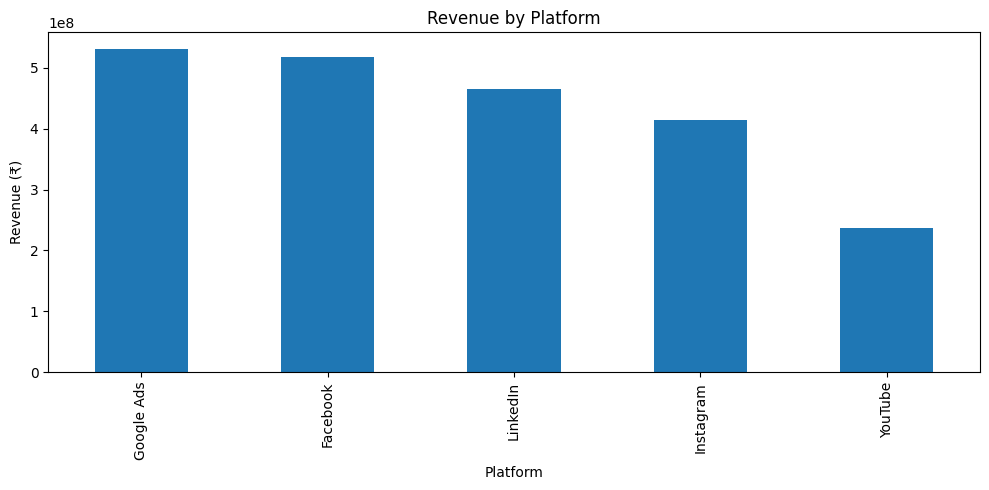

In [21]:
import matplotlib.pyplot as plt

platform_revenue.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue by Platform")
plt.ylabel("Revenue (₹)")
plt.xlabel("Platform")
plt.tight_layout()

plt.show()

Top 10 Campaigns by Revenue

In [22]:
df.groupby("CampaignName")["Revenue (₹)"]\
  .sum()\
  .sort_values(ascending=False)\
  .head(10)

CampaignName
UG Admission                 5.319735e+08
MBA Admission                5.172759e+08
Placements                   4.646099e+08
Semester Exchange Program    4.149747e+08
Hackathon                    2.366285e+08
Name: Revenue (₹), dtype: float64

Top 10 Campaigns by ROAS

In [23]:
df.groupby("CampaignName")["ROAS"]\
  .mean()\
  .sort_values(ascending=False)\
  .head(10)

CampaignName
Placements                   26.616496
Hackathon                    25.795047
Semester Exchange Program    25.148517
MBA Admission                24.586625
UG Admission                 24.504883
Name: ROAS, dtype: float64

    Top 10 Campaigns by Enrollments

In [24]:
df.groupby("CampaignName")["Enrollments"]\
  .sum()\
  .sort_values(ascending=False)\
  .head(10)

CampaignName
UG Admission                 95402
MBA Admission                94199
Placements                   83522
Semester Exchange Program    75249
Hackathon                    43942
Name: Enrollments, dtype: int64

Revenue by Region

In [25]:
df.groupby("Region")["Revenue (₹)"]\
  .sum()\
  .sort_values(ascending=False)

Region
Pan India      4.705046e+08
North India    4.653231e+08
West India     4.447013e+08
East India     4.074325e+08
South India    3.775010e+08
Name: Revenue (₹), dtype: float64

Revenue by Target Audience

In [26]:
df.groupby("TargetAudience")["Revenue (₹)"]\
  .sum()\
  .sort_values(ascending=False)

TargetAudience
17–21 Age    9.039015e+08
21–35 Age    5.172759e+08
22–27 Age    4.023658e+08
25–35 Age    3.419193e+08
Name: Revenue (₹), dtype: float64

In [27]:
df.to_csv(
    r"D:\Marketing_Campaign_Analysis\dataset\cleaned\marketing_campaign_clean.csv",
    index=False
)